# Explore raw data of EEG

In [3]:
# Magic command
%load_ext autoreload
%autoreload 2
%matplotlib inline

# Path setup
import sys
sys.path.append('..')

# Standard scientific stack
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# EEG-specific
import mne
mne.set_log_level('WARNING')

# Reproducibility
np.random.seed(42)

# Styling
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (12, 4)

## 1. Data load

In [4]:
edf_path = '../physionet.org/files/eegmmidb/1.0.0/S001/S001R03.edf'
raw = mne.io.read_raw_edf(edf_path, preload=True)
raw

<RawEDF | S001R03.edf, 64 x 20000 (125.0 s), ~9.8 MiB, data loaded>

## 2. Check Metadata

In [5]:
raw.info

<Info | 8 non-empty values
 bads: []
 ch_names: Fc5., Fc3., Fc1., Fcz., Fc2., Fc4., Fc6., C5.., C3.., C1.., ...
 chs: 64 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 80.0 Hz
 meas_date: 2009-08-12 16:15:00 UTC
 nchan: 64
 projs: []
 sfreq: 160.0 Hz
 subject_info: <subject_info | his_id: X, sex: 0, last_name: X>
>

In [6]:
data = raw.get_data()
print(data.shape)
print(data)

(64, 20000)
[[-5.70e-05 -4.90e-05 -5.50e-05 ...  0.00e+00  0.00e+00  0.00e+00]
 [-1.30e-05 -1.10e-05 -1.70e-05 ...  0.00e+00  0.00e+00  0.00e+00]
 [-1.50e-05 -1.00e-05 -1.60e-05 ...  0.00e+00  0.00e+00  0.00e+00]
 ...
 [-5.60e-05 -7.00e-05 -7.70e-05 ...  0.00e+00  0.00e+00  0.00e+00]
 [-1.24e-04 -1.49e-04 -1.53e-04 ...  0.00e+00  0.00e+00  0.00e+00]
 [-2.80e-05 -4.00e-05 -3.70e-05 ...  0.00e+00  0.00e+00  0.00e+00]]


## 3. Visualization

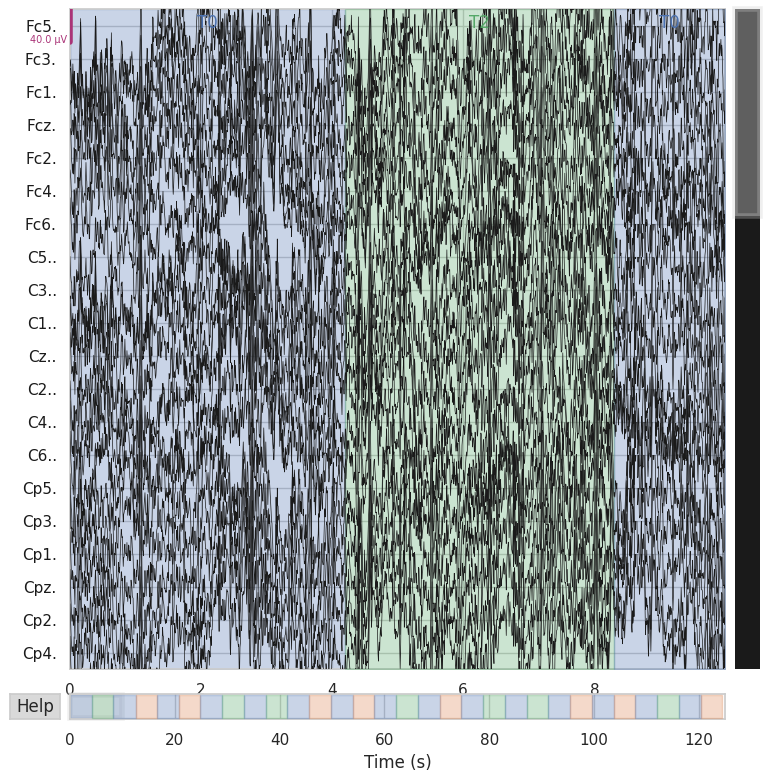

<Annotations | 30 segments: T0 (15), T1 (8), T2 (7)>


In [10]:
raw.plot()
print(raw.annotations)

## 3. Result

- Data: 64 ch, 160hz, 25 sec
- Event: T0 (rest), T1(Left), T2(Right), balanced between left and right
- Preprocessing needed: 8 to 30 hz band-pass filter
- Next: Filtering and epochs